# Chapter 146 — Vectorization for Performance

> **Prerequisites:** ch123 (Vectors in Programming), ch125–126 (Addition, Scalar Multiplication), ch145 (Vectors in ML)  
> **You will learn:**
> - Why Python loops are slow and how vectorized NumPy operations avoid them
> - Broadcasting: NumPy's rules for operating on arrays of different shapes
> - How to rewrite loop-based computations as pure array operations
> - Memory layout, SIMD, and why vectorization is fast
> - Practical patterns: pairwise distances, batch dot products, outer products
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Vectorization** means replacing explicit Python loops with array-level operations that execute in compiled code (C/Fortran) under the hood. The mathematical content is identical — you are computing the same values — but the execution is 10–1000× faster.

There are two distinct meanings of "vectorization" in this context:

1. **Mathematical vectorization:** Expressing a computation as a vector/matrix operation (dot products, norms, matrix multiply) rather than as element-wise loops.
2. **Hardware vectorization (SIMD):** Modern CPUs process multiple floating-point numbers simultaneously using SIMD (Single Instruction, Multiple Data) instructions. NumPy operations automatically exploit this.

**Why it matters:** In ML, you operate on datasets of millions of samples and models with millions of parameters. A Python loop over samples runs at ~10⁷ operations/second. A vectorized NumPy/GPU operation runs at ~10¹⁰–10¹². The difference is not cosmetic — it determines whether a model trains in 10 seconds or 3 hours.

**Common misconception:** "Vectorization is an optimization I can add later." No — it fundamentally changes how you think about computations. Writing ML code in loops first and vectorizing second is a path to incorrect, slow code.

---

## 2. Intuition & Mental Models

**Loop model:** Think of a Python loop as a single worker processing one item at a time, with significant overhead (interpreter, type checks, object dispatch) per item.

**Vectorized model:** Think of a NumPy operation as a factory conveyor belt — all items loaded at once, processed in parallel by optimized machinery (BLAS, LAPACK, SIMD), with overhead paid once.

**Broadcasting model:** NumPy broadcasting is the rule that allows operations on arrays of different shapes by conceptually "stretching" the smaller array. Think of it as implicit tiling: instead of explicitly repeating a row vector N times to match a matrix, NumPy applies the operation as if the repetition happened, without allocating the extra memory.

Recall from ch125 (Vector Addition): adding two vectors is a per-element operation. Broadcasting extends this so that adding a vector to a matrix adds the vector to each row — without a loop.

**Memory model:** NumPy arrays store data in contiguous blocks of memory. C-contiguous arrays (row-major) allow row operations to read sequential memory — cache-friendly. Column operations on C arrays jump in memory — cache-unfriendly. Layout matters for performance.

---

## 3. Visualization

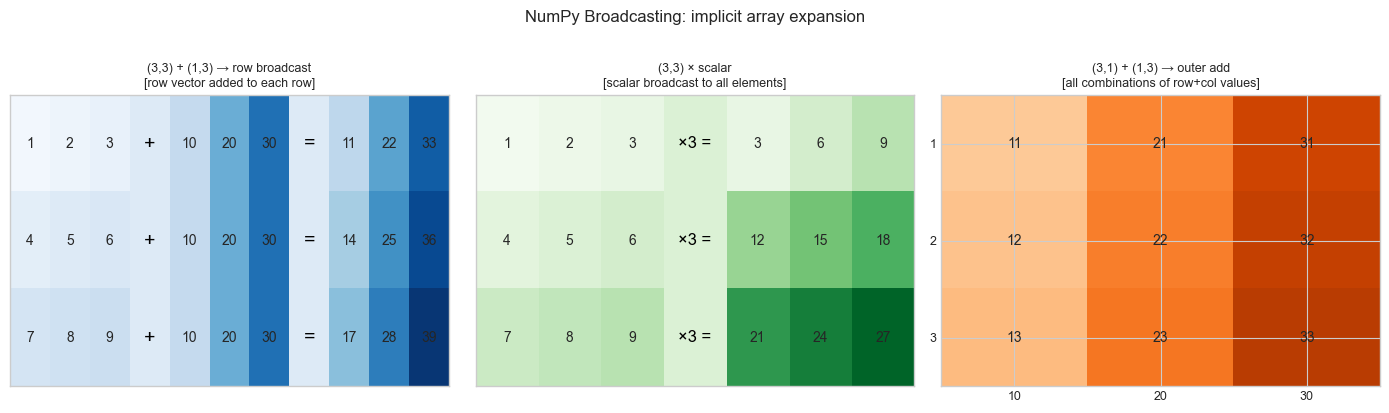

In [1]:
# --- Visualization: Broadcasting rules diagram ---

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def draw_array(ax, data, title, row_label=None, col_label=None, cmap='Blues'):
    """Draw a small array as a colored grid."""
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=data.max()+1, aspect='auto')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i,j]:.0f}', ha='center', va='center', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)

# Example 1: (3,3) + (1,3) -> broadcast row across all rows
A = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=float)
b_row = np.array([[10,20,30]], dtype=float)  # shape (1,3)
result = A + b_row

# Show side by side
ax = axes[0]
combined = np.hstack([A, 0.5*np.ones((3,1)), np.tile(b_row,(3,1)), 0.5*np.ones((3,1)), result])
ax.imshow(np.hstack([A, np.ones((3,1))*5, np.tile(b_row,(3,1)), np.ones((3,1))*5, result]),
           cmap='Blues', vmin=0, vmax=40, aspect='auto')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{A[i,j]:.0f}', ha='center', va='center', fontsize=10)
    ax.text(3, i, '+', ha='center', va='center', fontsize=14, color='black')
    for j in range(3):
        ax.text(4+j, i, f'{b_row[0,j]:.0f}', ha='center', va='center', fontsize=10)
    ax.text(7, i, '=', ha='center', va='center', fontsize=14, color='black')
    for j in range(3):
        ax.text(8+j, i, f'{result[i,j]:.0f}', ha='center', va='center', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('(3,3) + (1,3) → row broadcast\n[row vector added to each row]', fontsize=9)

# Example 2: scalar broadcasting
ax2 = axes[1]
A2 = np.arange(1, 10, dtype=float).reshape(3,3)
result2 = A2 * 3
ax2.imshow(np.hstack([A2, np.ones((3,1))*5, result2]), cmap='Greens', vmin=0, vmax=30, aspect='auto')
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f'{A2[i,j]:.0f}', ha='center', va='center', fontsize=10)
    ax2.text(3, i, '×3 =', ha='center', va='center', fontsize=12, color='black')
    for j in range(3):
        ax2.text(4+j, i, f'{result2[i,j]:.0f}', ha='center', va='center', fontsize=10)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title('(3,3) × scalar\n[scalar broadcast to all elements]', fontsize=9)

# Example 3: outer product pattern (3,1) + (1,3)
ax3 = axes[2]
col = np.array([[1],[2],[3]], dtype=float)  # shape (3,1)
row = np.array([[10,20,30]], dtype=float)   # shape (1,3)
result3 = col + row  # shape (3,3)
im = ax3.imshow(result3, cmap='Oranges', vmin=0, vmax=40, aspect='auto')
for i in range(3):
    for j in range(3):
        ax3.text(j, i, f'{result3[i,j]:.0f}', ha='center', va='center', fontsize=10)
ax3.set_xticks(range(3)); ax3.set_xticklabels([10,20,30], fontsize=9)
ax3.set_yticks(range(3)); ax3.set_yticklabels([1,2,3], fontsize=9)
ax3.set_title('(3,1) + (1,3) → outer add\n[all combinations of row+col values]', fontsize=9)

plt.suptitle('NumPy Broadcasting: implicit array expansion', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Broadcasting rule:** Two shapes are compatible if, aligned from the right, each dimension pair is either equal or one of them is 1.
```
A: (4, 3, 2)
B:    (3, 2)   → compatible (B broadcast over 4)
B:    (1, 2)   → compatible (B broadcast over 4×3)
B:    (5, 2)   → ERROR (5 ≠ 4 and neither is 1)
```

**Vectorized forms of common ML operations:**
```
Batch prediction:         ŷ = X @ w + b         [shape (N,) from (N,d)@(d,)]
Pairwise distances:       D[i,j] = ||xᵢ - xⱼ||   [shape (N,N) without any loop]
Cosine similarity matrix: C = X_norm @ X_normᵀ  [shape (N,N)]
Outer product:            M = np.outer(a, b)     [shape (m,n) from (m,)×(n,)]
Element-wise sigmoid:     σ(z) = 1/(1+exp(-z))  [shape preserved, no loop]
```

**Pairwise distance without a loop** (key pattern):
```
||xᵢ - xⱼ||² = ||xᵢ||² + ||xⱼ||² - 2xᵢ·xⱼ

In matrix form:
D² = norms[:,None] + norms[None,:] - 2*(X @ Xᵀ)
```
where `norms[i] = ||xᵢ||²`. This computes all N² distances in one matrix multiplication.

**Memory layout:**
- C-contiguous (row-major): A[0,0], A[0,1], A[0,2], A[1,0], ... → row operations fast
- F-contiguous (column-major): A[0,0], A[1,0], A[2,0], A[0,1], ... → column operations fast
- Transposing creates a view; no copy. `A.T` is just a stride change.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Vectorized vs loop versions of common operations ---

import numpy as np
import time


def pairwise_distances_loop(X):
    """
    Compute pairwise Euclidean distance matrix using explicit loops.
    O(N² · d) with Python loop overhead.
    """
    N = X.shape[0]
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            D[i, j] = np.sqrt(np.sum((X[i] - X[j])**2))
    return D


def pairwise_distances_vectorized(X):
    """
    Compute pairwise Euclidean distance matrix using broadcasting.
    ||xi - xj||² = ||xi||² + ||xj||² - 2 xi·xj

    Shape: (N, d) -> (N, N)
    """
    sq_norms = np.sum(X**2, axis=1)              # shape (N,)
    # Broadcasting: (N,1) + (1,N) - 2*(N,N) -> (N,N)
    D_sq = sq_norms[:, None] + sq_norms[None, :] - 2 * (X @ X.T)
    D_sq = np.maximum(D_sq, 0.)                  # numerical safety
    return np.sqrt(D_sq)


def batch_prediction_loop(X, w, b):
    """Linear prediction via loop — slow."""
    return np.array([np.dot(w, x) + b for x in X])


def batch_prediction_vectorized(X, w, b):
    """Linear prediction via matrix-vector product — fast."""
    return X @ w + b   # shape (N,)


# --- Benchmark ---
rng = np.random.default_rng(0)
N, D = 300, 50
X = rng.standard_normal((N, D))
w = rng.standard_normal(D)
b = 0.5

print("=== Pairwise distances ===")
t0 = time.perf_counter()
D_loop = pairwise_distances_loop(X[:50])  # only 50 for loop (too slow otherwise)
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
D_vec = pairwise_distances_vectorized(X)
t_vec = time.perf_counter() - t0

print(f"  Loop (N=50):       {t_loop*1000:.1f} ms")
print(f"  Vectorized (N={N}): {t_vec*1000:.2f} ms")
print(f"  Results match (N=50): {np.allclose(D_loop, D_vec[:50,:50], atol=1e-6)}")

print("\n=== Batch prediction ===")
t0 = time.perf_counter()
for _ in range(100): y_loop = batch_prediction_loop(X, w, b)
t_loop = (time.perf_counter() - t0) / 100

t0 = time.perf_counter()
for _ in range(100): y_vec = batch_prediction_vectorized(X, w, b)
t_vec = (time.perf_counter() - t0) / 100

print(f"  Loop:        {t_loop*1000:.3f} ms")
print(f"  Vectorized:  {t_vec*1000:.3f} ms")
print(f"  Speedup:     {t_loop/t_vec:.1f}x")
print(f"  Results match: {np.allclose(y_loop, y_vec)}")

=== Pairwise distances ===
  Loop (N=50):       33.6 ms
  Vectorized (N=300): 126.01 ms
  Results match (N=50): True

=== Batch prediction ===
  Loop:        1.621 ms
  Vectorized:  0.023 ms
  Speedup:     71.6x
  Results match: True


In [3]:
# --- Broadcasting patterns library ---

import numpy as np


def normalize_rows(X):
    """
    L2-normalize each row of X.
    Uses broadcasting: divide (N,d) by (N,1).
    """
    norms = np.linalg.norm(X, axis=1, keepdims=True)  # shape (N, 1)
    return X / (norms + 1e-12)  # broadcasts: (N,d) / (N,1)


def center_columns(X):
    """
    Subtract column mean from each column (zero-center features).
    Uses broadcasting: (N,d) - (1,d).
    """
    col_means = X.mean(axis=0, keepdims=True)  # shape (1, d)
    return X - col_means  # broadcasts: (N,d) - (1,d)


def softmax(z):
    """
    Softmax of a 1D or 2D array (row-wise for 2D).
    Numerically stable: subtract max before exp.
    """
    if z.ndim == 1:
        z = z - z.max()  # stability
        e = np.exp(z)
        return e / e.sum()
    else:  # 2D: row-wise
        z = z - z.max(axis=1, keepdims=True)  # (N,1) broadcast
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)


def outer_add(a, b):
    """
    Outer sum: M[i,j] = a[i] + b[j]
    Uses broadcasting: (m,1) + (1,n) -> (m,n)
    """
    return a[:, None] + b[None, :]  # no loop, no explicit tiling


# --- Verify each ---
rng = np.random.default_rng(1)
X = rng.standard_normal((5, 4))

X_norm = normalize_rows(X)
print("Row norms after normalize_rows:", np.linalg.norm(X_norm, axis=1).round(6))

X_centered = center_columns(X)
print("Column means after center_columns:", X_centered.mean(axis=0).round(10))

z = np.array([1., 2., 3., 4.])
sm = softmax(z)
print(f"Softmax: {sm.round(4)}, sum={sm.sum():.6f}")

a = np.array([1., 2., 3.])
b = np.array([10., 20.])
print(f"Outer add:\n{outer_add(a, b)}")

Row norms after normalize_rows: [1. 1. 1. 1. 1.]
Column means after center_columns: [-0.  0. -0.  0.]
Softmax: [0.0321 0.0871 0.2369 0.6439], sum=1.000000
Outer add:
[[11. 21.]
 [12. 22.]
 [13. 23.]]


---

## 6. Experiments

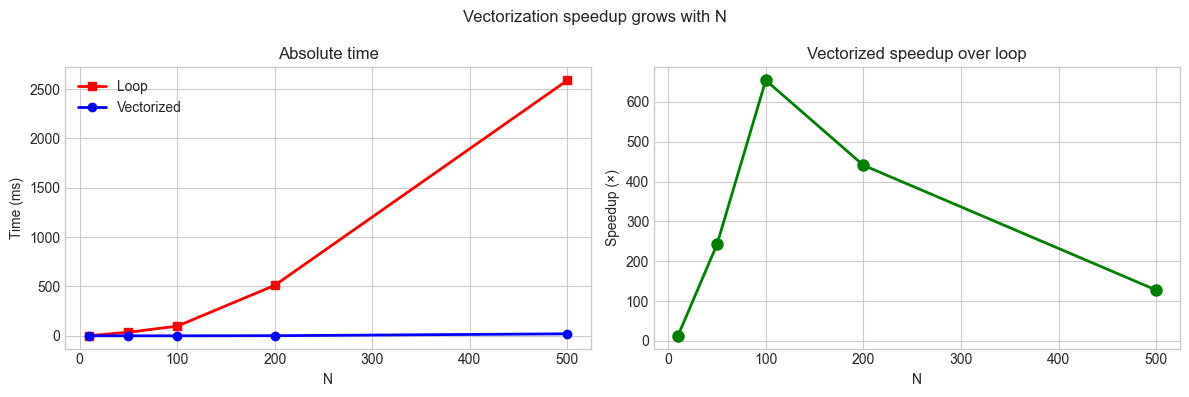

     N     loop (ms)    vec (ms)   speedup
    10           1.3       0.099      13.0x
    50          36.7       0.151     242.4x
   100          97.4       0.149     654.4x
   200         511.2       1.159     441.2x
   500        2588.8      20.236     127.9x


In [4]:
# --- Experiment 1: Speedup scaling with N ---
# Hypothesis: Vectorized code scales as O(N) wall time; loop scales as O(N²).

import numpy as np
import time
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

N_vals = [10, 50, 100, 200, 500]   # <-- try larger if patience allows
D = 20
rng = np.random.default_rng(0)

times_loop = []
times_vec  = []

for N in N_vals:
    X = rng.standard_normal((N, D))

    t0 = time.perf_counter()
    _ = pairwise_distances_loop(X)
    times_loop.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    for _ in range(20): _ = pairwise_distances_vectorized(X)
    times_vec.append((time.perf_counter() - t0) / 20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(N_vals, [t*1000 for t in times_loop], 'rs-', lw=2, label='Loop')
axes[0].plot(N_vals, [t*1000 for t in times_vec],  'bo-', lw=2, label='Vectorized')
axes[0].set_xlabel('N'); axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Absolute time')
axes[0].legend()

speedups = [l/v for l,v in zip(times_loop, times_vec)]
axes[1].plot(N_vals, speedups, 'go-', lw=2, markersize=8)
axes[1].set_xlabel('N'); axes[1].set_ylabel('Speedup (×)')
axes[1].set_title('Vectorized speedup over loop')

plt.suptitle('Vectorization speedup grows with N', fontsize=12)
plt.tight_layout()
plt.show()

print(f"{'N':>6}  {'loop (ms)':>12}  {'vec (ms)':>10}  {'speedup':>8}")
for N, tl, tv, sp in zip(N_vals, times_loop, times_vec, speedups):
    print(f"  {N:4d}  {tl*1000:12.1f}  {tv*1000:10.3f}  {sp:8.1f}x")

In [5]:
# --- Experiment 2: Broadcasting shapes ---
# Understand which shape combinations broadcast successfully.

import numpy as np

shape_pairs = [
    ((5, 3), (3,)),       # row vector added to each row of matrix
    ((5, 3), (5, 1)),     # column vector added to each column
    ((5, 3), (1, 3)),     # same as first
    ((5, 1, 3), (4, 3)),  # 3D broadcasting
    ((5, 3), (4, 3)),     # should FAIL: 5 != 4
]

print("Broadcasting compatibility tests:")
for s1, s2 in shape_pairs:
    try:
        A = np.zeros(s1)
        B = np.zeros(s2)
        C = A + B
        print(f"  {str(s1):>15} + {str(s2):>10} -> {str(C.shape):>15}  ✓")
    except ValueError as e:
        print(f"  {str(s1):>15} + {str(s2):>10} -> ERROR: {e}")

Broadcasting compatibility tests:
           (5, 3) +       (3,) ->          (5, 3)  ✓
           (5, 3) +     (5, 1) ->          (5, 3)  ✓
           (5, 3) +     (1, 3) ->          (5, 3)  ✓
        (5, 1, 3) +     (4, 3) ->       (5, 4, 3)  ✓
           (5, 3) +     (4, 3) -> ERROR: operands could not be broadcast together with shapes (5,3) (4,3) 


---

## 7. Exercises

**Easy 1.** Rewrite the following loop without any Python loops:
```python
result = []
for i in range(len(x)):
    result.append(x[i]**2 + 2*x[i] + 1)
```

**Easy 2.** What is the output shape of `np.ones((4,1,3)) + np.ones((5,3))`? Explain using the broadcasting rules.

**Medium 1.** Implement `zscore_normalize(X)` — subtract the column mean and divide by column std — using broadcasting only (no loops). Verify that the result has mean ≈ 0 and std ≈ 1 per column.

**Medium 2.** Implement the pairwise cosine similarity matrix for a set of N vectors using only `@`, broadcasting, and `np.linalg.norm`. No loops. Time it against a double-loop version for N=500, d=100.

**Hard.** Implement a vectorized k-means clustering update step: given data matrix X (N×d) and cluster centers C (k×d), (a) assign each point to its nearest center (vectorized), (b) update each center to the mean of its assigned points. No Python loops over samples or clusters.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Vectorized k-NN Classifier ---
#
# Implement a fully vectorized k-NN classifier — no Python loops over samples.
# Compare performance against the loop-based version from ch145.

import numpy as np
import time
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(0)

# Dataset
N_TRAIN, N_TEST, D = 500, 200, 10
X_train = np.vstack([
    rng.multivariate_normal(np.zeros(D), np.eye(D), N_TRAIN//2),
    rng.multivariate_normal(3*np.ones(D), np.eye(D), N_TRAIN//2),
])
y_train = np.array([0]*(N_TRAIN//2) + [1]*(N_TRAIN//2))
X_test = np.vstack([
    rng.multivariate_normal(np.zeros(D), np.eye(D), N_TEST//2),
    rng.multivariate_normal(3*np.ones(D), np.eye(D), N_TEST//2),
])
y_test = np.array([0]*(N_TEST//2) + [1]*(N_TEST//2))


def knn_vectorized(X_train, y_train, X_test, k=5):
    """
    Fully vectorized k-NN: no Python loops over samples.

    Computes all pairwise distances in one matrix operation.
    """
    # Pairwise squared distances: (N_test, N_train)
    # ||xi - xj||² = ||xi||² + ||xj||² - 2 xi·xj
    sq_test  = np.sum(X_test**2, axis=1)[:, None]    # (N_test, 1)
    sq_train = np.sum(X_train**2, axis=1)[None, :]   # (1, N_train)
    cross    = X_test @ X_train.T                     # (N_test, N_train)
    D_sq = np.maximum(sq_test + sq_train - 2*cross, 0.)

    # For each test point, get indices of k nearest training points
    knn_idx = np.argpartition(D_sq, k, axis=1)[:, :k]  # (N_test, k)

    # Majority vote — still requires a small loop or np.apply_along_axis
    neighbor_labels = y_train[knn_idx]   # (N_test, k)
    predictions = (neighbor_labels.sum(axis=1) > k//2).astype(int)
    return predictions


# Time comparison
t0 = time.perf_counter()
preds_vec = knn_vectorized(X_train, y_train, X_test, k=7)
t_vec = time.perf_counter() - t0

# Loop version from ch145
def knn_loop(X_train, y_train, X_test, k=5):
    predictions = []
    for x in X_test:
        dists = np.linalg.norm(X_train - x, axis=1)
        knn_idx = np.argsort(dists)[:k]
        predictions.append(np.bincount(y_train[knn_idx]).argmax())
    return np.array(predictions)

t0 = time.perf_counter()
preds_loop = knn_loop(X_train, y_train, X_test, k=7)
t_loop = time.perf_counter() - t0

acc_vec  = np.mean(preds_vec == y_test)
acc_loop = np.mean(preds_loop == y_test)

print(f"Vectorized k-NN: accuracy={acc_vec:.3f}, time={t_vec*1000:.2f} ms")
print(f"Loop k-NN:       accuracy={acc_loop:.3f}, time={t_loop*1000:.2f} ms")
print(f"Speedup: {t_loop/t_vec:.1f}x")
print(f"Results identical: {np.all(preds_vec == preds_loop)}")

---

## 9. Chapter Summary & Connections

**What was covered:**
- Vectorization replaces Python loops with array-level operations executed in compiled code.
- Broadcasting allows operations on arrays of different shapes without explicit tiling or loops.
- The pairwise distance trick (`‖xᵢ−xⱼ‖² = ‖xᵢ‖² + ‖xⱼ‖² − 2xᵢ·xⱼ`) computes N² distances in one matrix multiplication.
- Speedups of 10–1000× are typical; the gap widens with N.
- Memory layout (C vs F contiguous) affects cache performance.

**Backward connection:** The mathematical operations (dot products, norms, outer products) are the same as ch131–136 *(introduced there)*. This chapter is about executing them efficiently at scale — the computational realization of the math.

**Forward connections:**
- In ch147 (NumPy Vector Operations), the full NumPy API for vectorized computation is surveyed systematically.
- This will reappear in ch188 (Linear Layers in Deep Learning): a layer's forward pass is a single matrix multiplication `XW + b` — entirely vectorized, running on GPU BLAS.
- In ch228 (Gradient-Based Learning), the gradient of a batch loss requires vectorized Jacobian-vector products — impossible to compute efficiently in loops.